### Separate notebook just to run and compare final algorith more cleanly // no need to have the whole exploration process in the same place

In [1]:
import numpy as np 
from bandit import Bandits_final

In [2]:
def epsilon_greedy(MAB, episodes=1000, epsilon=0.1):
    num_arms = MAB.k

    estimated_rewards = np.zeros(num_arms)
    action_counts = np.zeros(num_arms)

    actions = np.zeros(episodes, dtype=int)
    rewards = np.zeros(episodes)

    for ep in range(episodes):
        if np.random.rand() < epsilon:
            action = np.random.randint(num_arms)
        else:
            action = np.argmax(estimated_rewards)

        _, reward, _, _, _ = MAB.step(action)

        action_counts[action] += 1
        estimated_rewards[action] += (reward - estimated_rewards[action]) / action_counts[action]

        actions[ep] = action
        rewards[ep] = reward

    return actions, rewards, estimated_rewards, action_counts

In [3]:
def Custom_v1(MAB, episodes=1000, epsilon=0.1, alpha=5.0, window=20, short_window=3, k=4.0, reset_factor=0.5, reset_epsilon=0.3):
    num_arms = MAB.k

    estimated_rewards = np.zeros(num_arms)
    action_counts = np.zeros(num_arms)

    actions = np.zeros(episodes, dtype=int)
    rewards = np.zeros(episodes)
    trigger_steps = []

    current_epsilon = epsilon

    for ep in range(episodes):
        if np.random.rand() < current_epsilon:
            action = np.random.randint(num_arms)
        else:
            action = np.argmax(estimated_rewards)

        _, reward, _, _, _ = MAB.step(action)

        actions[ep] = action
        rewards[ep] = reward

        if ep >= window:
            long_recent = rewards[ep-window:ep]
            short_recent = rewards[ep-short_window:ep]
            ma = np.mean(long_recent)
            short_ma = np.mean(short_recent)
            std = np.std(long_recent)

            if std > 0 and abs(ma - short_ma) > k * std:
                estimated_rewards *= reset_factor
                current_epsilon = reset_epsilon
                trigger_steps.append(ep)

        action_counts[action] += 1
        estimated_rewards[action] += (reward - estimated_rewards[action]) / alpha

        if current_epsilon > epsilon:
            current_epsilon = max(epsilon, current_epsilon * 0.98)

    return actions, rewards, estimated_rewards, action_counts, np.array(trigger_steps)

### plot of moving average for eg, algo

In [4]:
def evaluate_Customized_algo(param_grid, episodes=1000, runs=20):
    results = []

    for epsilon in param_grid['epsilon']:
        for alpha in param_grid['alpha']:
            for window in param_grid['window']:
                for short_window in param_grid['short_window']:
                    for k in param_grid['k']:
                        for reset_factor in param_grid['reset_factor']:
                            for reset_epsilon in param_grid['reset_epsilon']:
                                total_rewards = []
                                trigger_counts = []

                                for _ in range(runs):
                                    MAB = Bandits_final()
                                    _, rewards, _, _, triggers = Custom_v1(
                                        MAB,
                                        episodes=episodes,
                                        epsilon=epsilon,
                                        alpha=alpha,
                                        window=window,
                                        short_window=short_window,
                                        k=k,
                                        reset_factor=reset_factor,
                                        reset_epsilon=reset_epsilon,
                                    )
                                    total_rewards.append(np.sum(rewards))
                                    trigger_counts.append(len(triggers))

                                results.append({
                                    'epsilon': epsilon,
                                    'alpha': alpha,
                                    'window': window,
                                    'short_window': short_window,
                                    'k': k,
                                    'reset_factor': reset_factor,
                                    'reset_epsilon': reset_epsilon,
                                    'mean_total_reward': np.mean(total_rewards),
                                    'std_total_reward': np.std(total_rewards),
                                    'mean_trigger_count': np.mean(trigger_counts),
                                    'std_trigger_count': np.std(trigger_counts),
                                })

    return sorted(results, key=lambda row: row['mean_total_reward'], reverse=True)

custom_param_grid = {
    'epsilon': [0.1, 0.15, 0.2],
    'alpha': [3.0, 5.0],
    'window': [10, 20],
    'short_window': [3, 5],
    'k': [1.25, 1.5, 2.0],
    'reset_factor': [0.2],
    'reset_epsilon': [0.5],
}

custom_sweep = evaluate_Customized_algo(custom_param_grid, episodes=1000, runs=20)
custom_sweep[:10]


[{'epsilon': 0.1,
  'alpha': 5.0,
  'window': 20,
  'short_window': 5,
  'k': 1.25,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3977.4639700969847),
  'std_total_reward': np.float64(496.60116083974515),
  'mean_trigger_count': np.float64(2.2),
  'std_trigger_count': np.float64(2.3151673805580453)},
 {'epsilon': 0.1,
  'alpha': 5.0,
  'window': 10,
  'short_window': 5,
  'k': 2.0,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3936.8441805308967),
  'std_total_reward': np.float64(592.0751767181948),
  'mean_trigger_count': np.float64(0.0),
  'std_trigger_count': np.float64(0.0)},
 {'epsilon': 0.1,
  'alpha': 3.0,
  'window': 10,
  'short_window': 3,
  'k': 2.0,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3904.8190333890134),
  'std_total_reward': np.float64(633.0370633061272),
  'mean_trigger_count': np.float64(0.0),
  'std_trigger_count': np.float64(0.0)},
 {'epsilon': 0.15,
  'a

In [5]:
# looking at the range where i suspect the trigger mechanism is working. 
trigger_filtered = [
    row for row in custom_sweep
    if 1 <= row['mean_trigger_count'] <= 10
]

trigger_filtered[:10]

[{'epsilon': 0.1,
  'alpha': 5.0,
  'window': 20,
  'short_window': 5,
  'k': 1.25,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3977.4639700969847),
  'std_total_reward': np.float64(496.60116083974515),
  'mean_trigger_count': np.float64(2.2),
  'std_trigger_count': np.float64(2.3151673805580453)},
 {'epsilon': 0.15,
  'alpha': 3.0,
  'window': 20,
  'short_window': 3,
  'k': 1.5,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3757.8009178479297),
  'std_total_reward': np.float64(696.6909539363617),
  'mean_trigger_count': np.float64(6.4),
  'std_trigger_count': np.float64(2.33238075793812)},
 {'epsilon': 0.1,
  'alpha': 3.0,
  'window': 20,
  'short_window': 5,
  'k': 1.25,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3748.6744266889827),
  'std_total_reward': np.float64(763.2997128740361),
  'mean_trigger_count': np.float64(1.35),
  'std_trigger_count': np.float64(1.589811309558

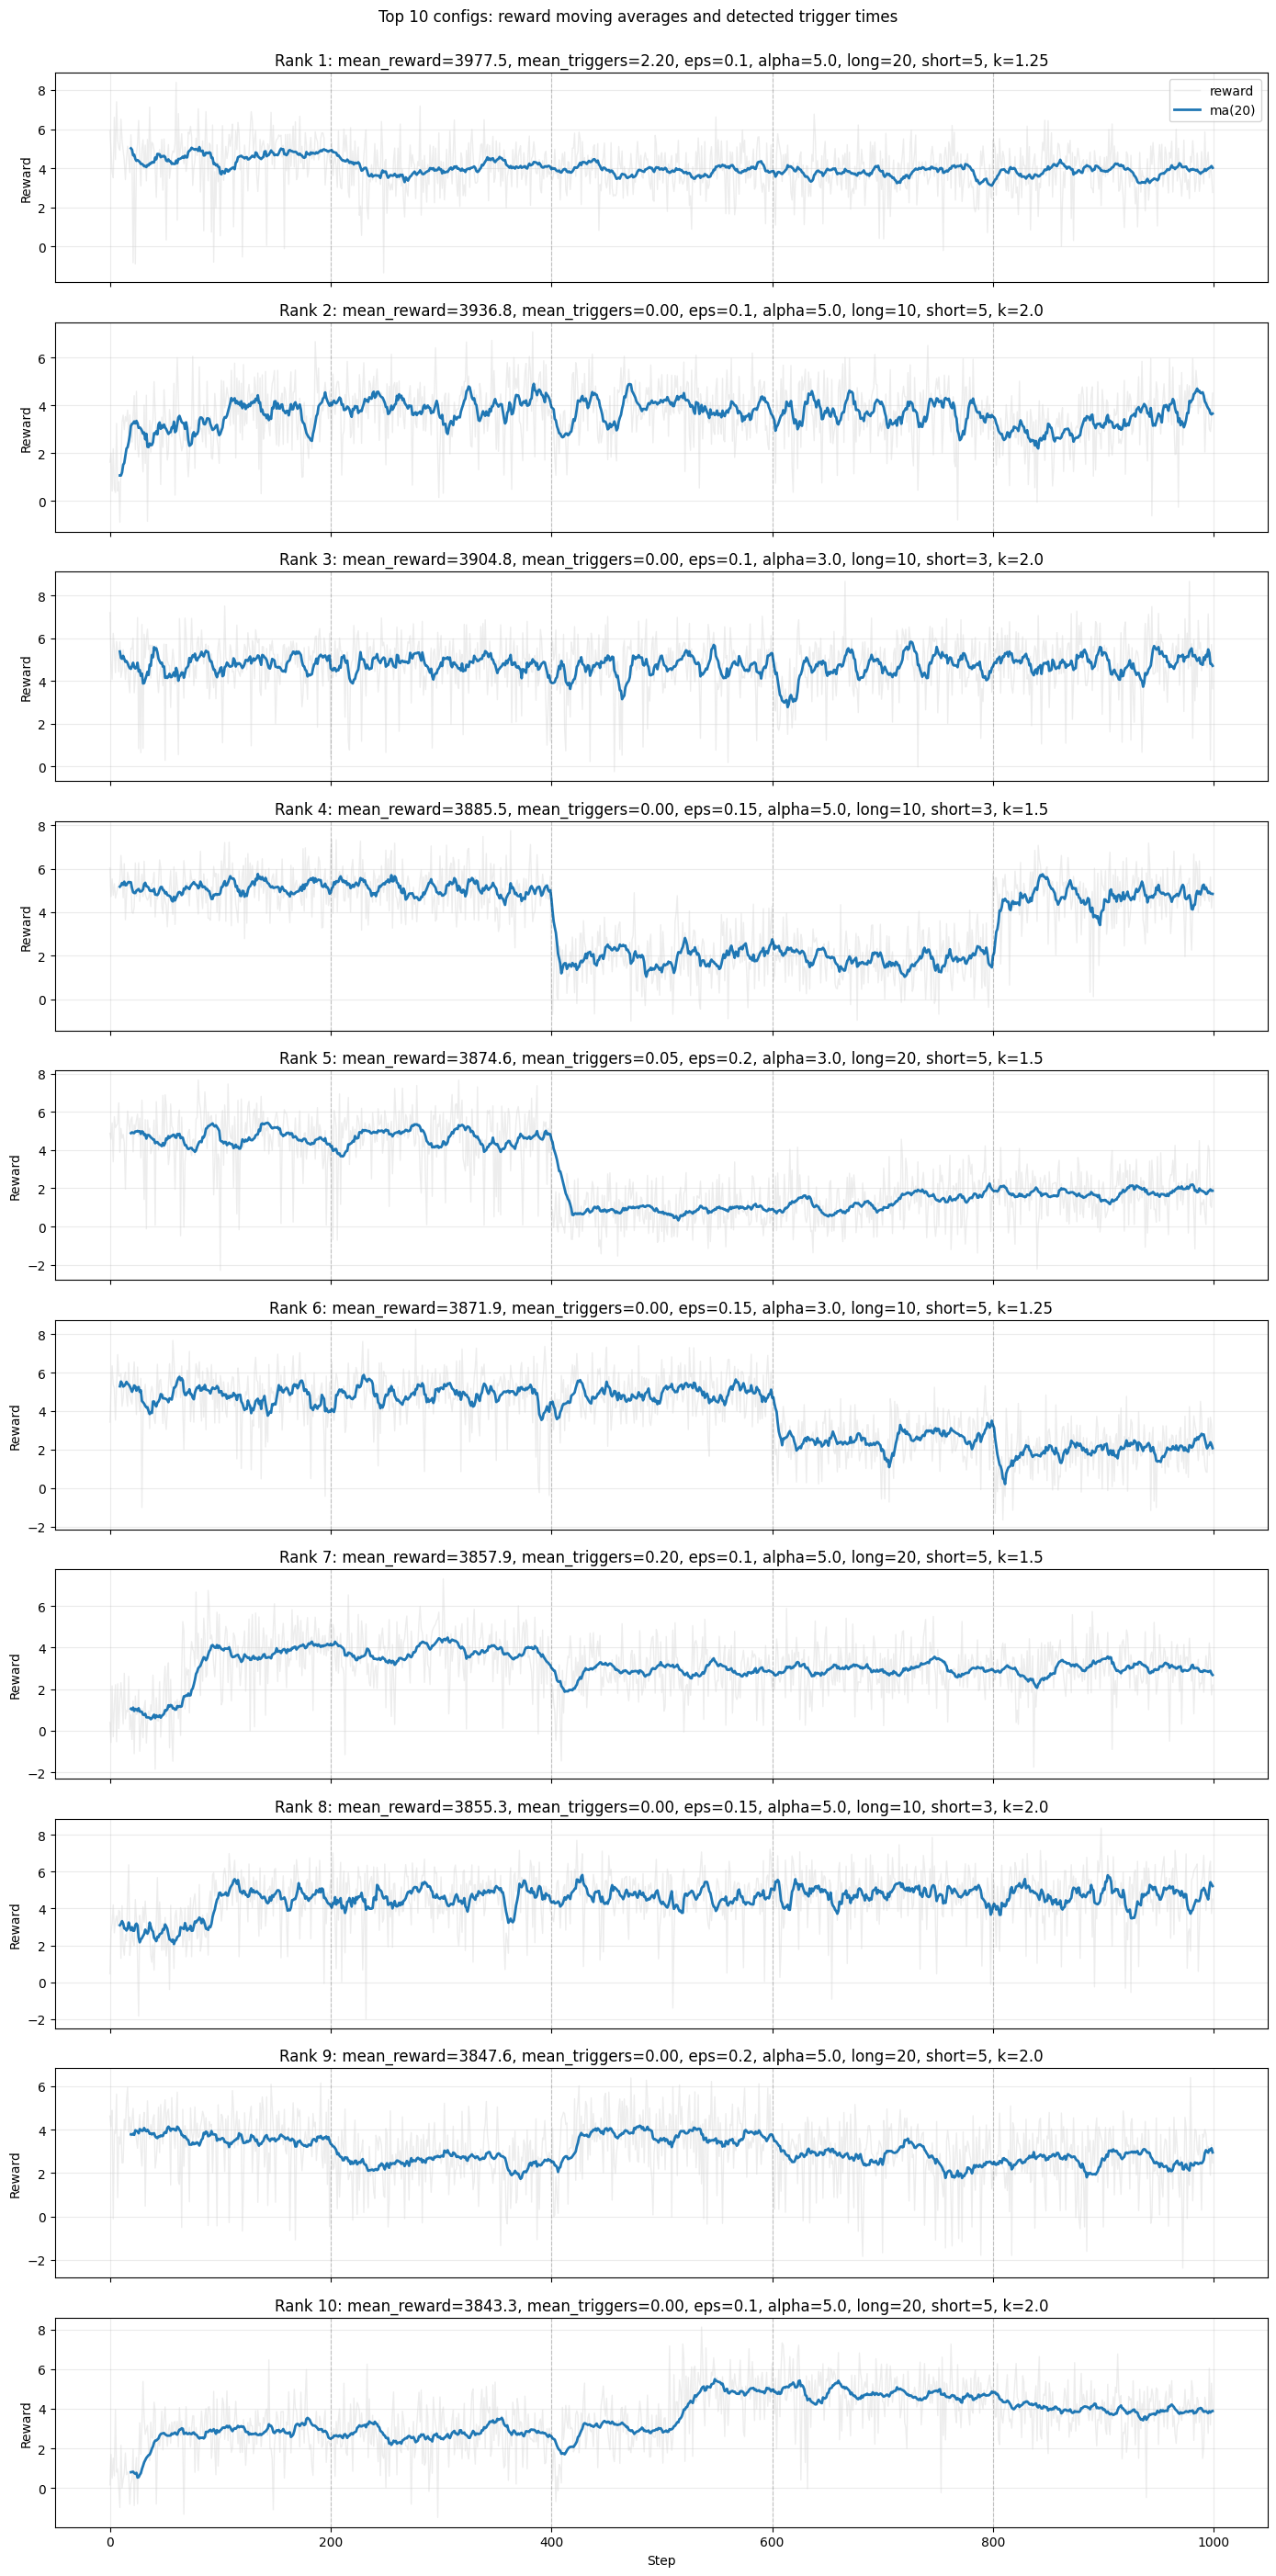

[{'rank': 1,
  'mean_total_reward': 3977.4639700969847,
  'mean_trigger_count': 2.2,
  'trigger_count_this_run': 0},
 {'rank': 2,
  'mean_total_reward': 3936.8441805308967,
  'mean_trigger_count': 0.0,
  'trigger_count_this_run': 0},
 {'rank': 3,
  'mean_total_reward': 3904.8190333890134,
  'mean_trigger_count': 0.0,
  'trigger_count_this_run': 0},
 {'rank': 4,
  'mean_total_reward': 3885.4901377997367,
  'mean_trigger_count': 0.0,
  'trigger_count_this_run': 0},
 {'rank': 5,
  'mean_total_reward': 3874.625225384733,
  'mean_trigger_count': 0.05,
  'trigger_count_this_run': 0},
 {'rank': 6,
  'mean_total_reward': 3871.854651157987,
  'mean_trigger_count': 0.0,
  'trigger_count_this_run': 0},
 {'rank': 7,
  'mean_total_reward': 3857.9186419105727,
  'mean_trigger_count': 0.2,
  'trigger_count_this_run': 0},
 {'rank': 8,
  'mean_total_reward': 3855.3101359782668,
  'mean_trigger_count': 0.0,
  'trigger_count_this_run': 0},
 {'rank': 9,
  'mean_total_reward': 3847.6403221797473,
  'mean_t

In [6]:
import matplotlib.pyplot as plt

def moving_average(rewards, window):
    rewards = np.asarray(rewards)
    window = int(window)
    if window <= 1 or len(rewards) < window:
        return np.arange(len(rewards)), rewards
    ma = np.convolve(rewards, np.ones(window) / window, mode='valid')
    x_ma = np.arange(window - 1, len(rewards))
    return x_ma, ma

top10_configs = custom_sweep[:10]
episodes = 1000
change_checkpoints = np.arange(200, episodes, 200)

fig, axes = plt.subplots(len(top10_configs), 1, figsize=(14, 2.8 * len(top10_configs)), sharex=True)
if len(top10_configs) == 1:
    axes = [axes]

top10_run_summary = []

for rank, (ax, config) in enumerate(zip(axes, top10_configs), start=1):
    _, rewards, _, _, triggers = Custom_v1(
        Bandits_final(),
        episodes=episodes,
        epsilon=config['epsilon'],
        alpha=config['alpha'],
        window=int(config['window']),
        short_window=int(config['short_window']),
        k=config['k'],
        reset_factor=config['reset_factor'],
        reset_epsilon=config['reset_epsilon'],
    )

    ma_window = int(config['window'])
    x_ma, reward_ma = moving_average(rewards, ma_window)

    ax.plot(rewards, color='lightgray', alpha=0.4, linewidth=1, label='reward')
    ax.plot(x_ma, reward_ma, color='tab:blue', linewidth=2, label=f'ma({ma_window})')

    for step in change_checkpoints:
        ax.axvline(step, color='black', linestyle='--', alpha=0.18, linewidth=0.8)
    for step in triggers:
        ax.axvline(step, color='tab:red', alpha=0.45, linewidth=1)

    ax.set_ylabel('Reward')
    ax.grid(True, alpha=0.25)
    ax.set_title(
        f"Rank {rank}: mean_reward={config['mean_total_reward']:.1f}, mean_triggers={config['mean_trigger_count']:.2f}, "
        f"eps={config['epsilon']}, alpha={config['alpha']}, long={int(config['window'])}, short={int(config['short_window'])}, k={config['k']}"
    )

    top10_run_summary.append({
        'rank': rank,
        'mean_total_reward': float(config['mean_total_reward']),
        'mean_trigger_count': float(config['mean_trigger_count']),
        'trigger_count_this_run': int(len(triggers)),
    })

axes[0].legend(loc='upper right')
axes[-1].set_xlabel('Step')
fig.suptitle('Top 10 configs: reward moving averages and detected trigger times', y=1.0)
plt.tight_layout()
plt.show()

top10_run_summary


In [7]:
def custom_v3 (MAB, episodes = 1000, epsilon = 0.15, alpha= 5):
    num_arms = MAB.k

    estimated_rewards = np.zeros(num_arms)
    action_counts = np.zeros(num_arms)

    actions = np.zeros(episodes, dtype=int)
    rewards = np.zeros(episodes)

    for ep in range(episodes):
        if np.random.rand() < epsilon:
            action = np.random.randint(num_arms)
        else:
            action = np.argmax(estimated_rewards)

        _, reward, _, _, _ = MAB.step(action)

        action_counts[action] += 1
        estimated_rewards[action] += (reward - estimated_rewards[action]) / alpha

        actions[ep] = action
        rewards[ep] = reward

    return actions, rewards, estimated_rewards, action_counts


In [8]:
def UCB(MAB,time,c):
    expected_rewards = np.zeros(MAB.k)   # estimated rewards|ai to zero
    action_count = np.zeros(MAB.k, dtype=int)  # action_counts initialized to zero

    actions = np.zeros(time, dtype=int)
    rewards = np.zeros(time)

    for t in range(1, time + 1):
        # evaluate UCB for all actions
        upper_bound = np.zeros(MAB.k)
        for i in range(MAB.k):
            if action_count[i] == 0:
                upper_bound[i] = np.inf   # force exploration
            else:
                upper_bound[i] = np.sqrt(np.log(t) / action_count[i])

        # select action that maximizes Q + c * U
        action = np.argmax(expected_rewards + c * upper_bound)

        # take action and observe reward
        observation, reward, terminated, truncated, info = MAB.step(action)

        # update counters and estimates
        action_count[action] += 1
        expected_rewards[action] += (reward - expected_rewards[action]) / action_count[action]


        actions[t - 1] = action
        rewards[t - 1] = reward
    return expected_rewards, action_count, actions, rewards

In [9]:
def custom_algo_v4(MAB, time=1000, c=2.0, window_length=25):
    effective_window = max(1, int(round(window_length)))
    expected_rewards = np.zeros(MAB.k)
    action_count = np.zeros(MAB.k, dtype=int)

    actions = np.zeros(time, dtype=int)
    rewards = np.zeros(time)

    for t in range(1, time + 1):
        start = max(0, (t - 1) - effective_window)
        recent_actions = actions[start:t - 1]
        recent_rewards = rewards[start:t - 1]

        window_means = np.zeros(MAB.k)
        upper_bound = np.zeros(MAB.k)

        for i in range(MAB.k):
            arm_mask = recent_actions == i
            arm_count = int(np.sum(arm_mask))
            if arm_count == 0:
                upper_bound[i] = np.inf
            else:
                window_means[i] = np.mean(recent_rewards[arm_mask])
                upper_bound[i] = np.sqrt(np.log(max(2, len(recent_actions) + 1)) / arm_count)

        action = np.argmax(window_means + c * upper_bound)
        _, reward, _, _, _ = MAB.step(action)

        action_count[action] += 1
        expected_rewards[action] += (reward - expected_rewards[action]) / action_count[action]

        actions[t - 1] = action
        rewards[t - 1] = reward

    return expected_rewards, action_count, actions, rewards


In [10]:
custom_params_final = {
    'epsilon': 0.15,
    'alpha': 5.0,
    'window': 20,
    'short_window': 3,
    'k': 1.5,
    'reset_factor': 0.2,
    'reset_epsilon': 0.5,
}


PLOT MA for custom algo 

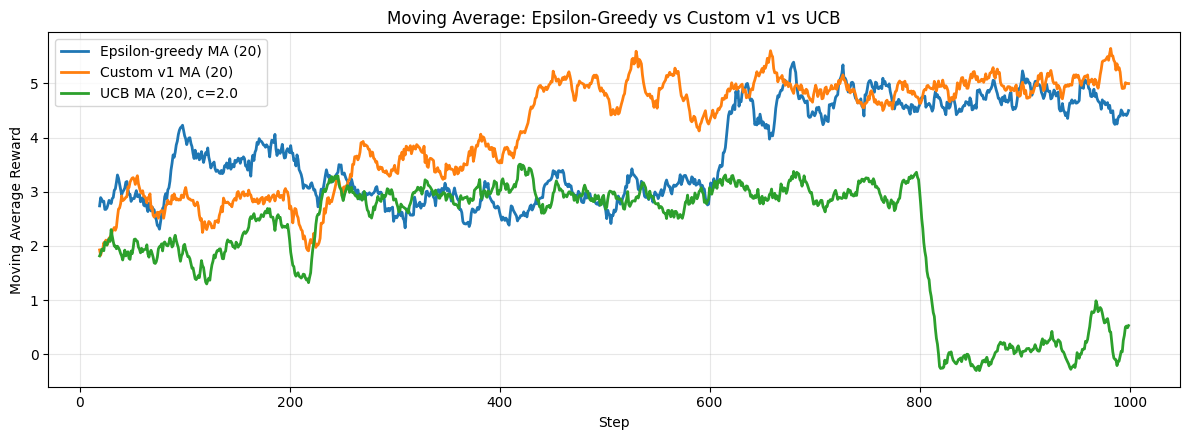

{'eg_total_reward': 3717.019773577152,
 'custom_v1_total_reward': 4148.60290407676,
 'custom_v1_trigger_count': 1,
 'ucb_total_reward': 2177.073384642049,
 'ucb_c': 2.0}

In [11]:
episodes = 1000
ma_window = int(custom_params_final['window'])
ucb_c = 2.0

_, eg_rewards, _, _ = epsilon_greedy(
    Bandits_final(),
    episodes=episodes,
    epsilon=custom_params_final['epsilon'],
)

_, custom_v1_rewards, _, _, custom_v1_triggers = Custom_v1(
    Bandits_final(),
    episodes=episodes,
    epsilon=custom_params_final['epsilon'],
    alpha=custom_params_final['alpha'],
    window=custom_params_final['window'],
    short_window=custom_params_final['short_window'],
    k=custom_params_final['k'],
    reset_factor=custom_params_final['reset_factor'],
    reset_epsilon=custom_params_final['reset_epsilon'],
)

_, _, _, ucb_rewards = UCB(
    Bandits_final(),
    time=episodes,
    c=ucb_c,
)

x_eg_ma, eg_ma = moving_average(eg_rewards, ma_window)
x_custom_ma, custom_v1_ma = moving_average(custom_v1_rewards, ma_window)
x_ucb_ma, ucb_ma = moving_average(ucb_rewards, ma_window)

plt.figure(figsize=(12, 4.5))
plt.plot(x_eg_ma, eg_ma, linewidth=2, label=f"Epsilon-greedy MA ({ma_window})")
plt.plot(x_custom_ma, custom_v1_ma, linewidth=2, label=f"Custom v1 MA ({ma_window})")
plt.plot(x_ucb_ma, ucb_ma, linewidth=2, label=f"UCB MA ({ma_window}), c={ucb_c}")
plt.title("Moving Average: Epsilon-Greedy vs Custom v1 vs UCB")
plt.xlabel("Step")
plt.ylabel("Moving Average Reward")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

{
    'eg_total_reward': float(np.sum(eg_rewards)),
    'custom_v1_total_reward': float(np.sum(custom_v1_rewards)),
    'custom_v1_trigger_count': int(len(custom_v1_triggers)),
    'ucb_total_reward': float(np.sum(ucb_rewards)),
    'ucb_c': float(ucb_c),
}


avg reward over 500 runs, custom v1, custom v2, eg, ucb, and custom_algo_v4 with sliding-window length 50

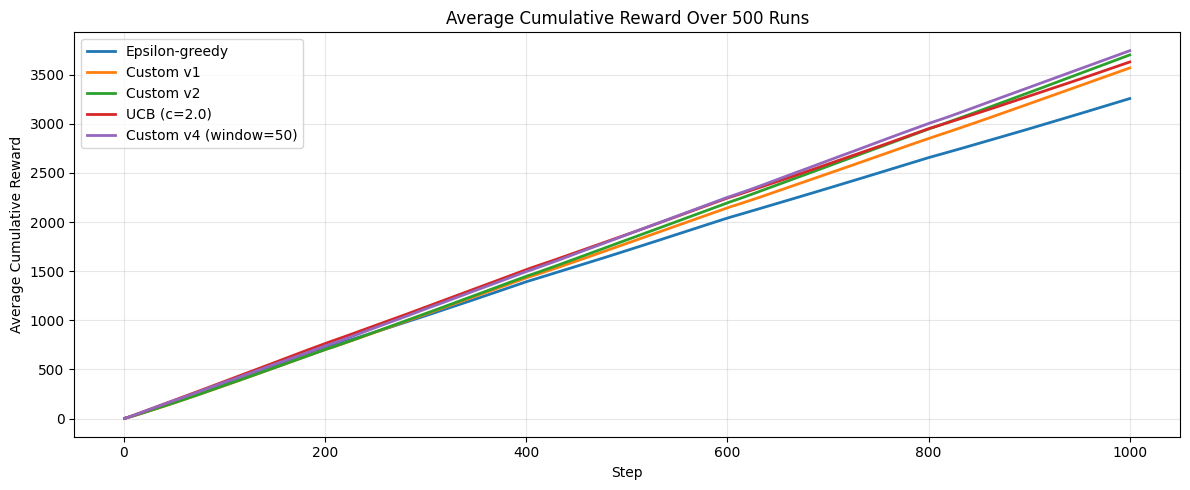

{'runs': 500,
 'eg_final_avg_cumulative_reward': 3257.005619374664,
 'custom_v1_final_avg_cumulative_reward': 3568.4608028667353,
 'custom_v2_final_avg_cumulative_reward': 3701.1172601038706,
 'ucb_final_avg_cumulative_reward': 3629.491715615494,
 'custom_v4_final_avg_cumulative_reward_window_50': 3744.028676346075,
 'custom_v4_effective_window_50': 50}

In [12]:
runs = 500
episodes = 1000
ucb_c = 2.0
custom_v4_window_length = 50
custom_v4_effective_window = max(1, int(round(custom_v4_window_length)))

eg_cum_runs = []
custom_v1_cum_runs = []
custom_v3_cum_runs = []
ucb_cum_runs = []
custom_v4_cum_runs = []

for _ in range(runs):
    _, eg_rewards, _, _ = epsilon_greedy(
        Bandits_final(),
        episodes=episodes,
        epsilon=custom_params_final['epsilon'],
    )
    eg_cum_runs.append(np.cumsum(eg_rewards))

    _, custom_v1_rewards, _, _, _ = Custom_v1(
        Bandits_final(),
        episodes=episodes,
        epsilon=custom_params_final['epsilon'],
        alpha=custom_params_final['alpha'],
        window=custom_params_final['window'],
        short_window=custom_params_final['short_window'],
        k=custom_params_final['k'],
        reset_factor=custom_params_final['reset_factor'],
        reset_epsilon=custom_params_final['reset_epsilon'],
    )
    custom_v1_cum_runs.append(np.cumsum(custom_v1_rewards))

    _, custom_v3_rewards, _, _ = custom_v3(
        Bandits_final(),
        episodes=episodes,
        epsilon=custom_params_final['epsilon'],
        alpha=custom_params_final['alpha'],
    )
    custom_v3_cum_runs.append(np.cumsum(custom_v3_rewards))

    _, _, _, ucb_rewards = UCB(
        Bandits_final(),
        time=episodes,
        c=ucb_c,
    )
    ucb_cum_runs.append(np.cumsum(ucb_rewards))

    _, _, _, custom_v4_rewards = custom_algo_v4(
        Bandits_final(),
        time=episodes,
        c=ucb_c,
        window_length=custom_v4_window_length,
    )
    custom_v4_cum_runs.append(np.cumsum(custom_v4_rewards))

eg_mean_cum = np.mean(np.asarray(eg_cum_runs), axis=0)
custom_v1_mean_cum = np.mean(np.asarray(custom_v1_cum_runs), axis=0)
custom_v2_mean_cum = np.mean(np.asarray(custom_v3_cum_runs), axis=0)
ucb_mean_cum = np.mean(np.asarray(ucb_cum_runs), axis=0)
custom_v4_mean_cum = np.mean(np.asarray(custom_v4_cum_runs), axis=0)

steps = np.arange(1, episodes + 1)

plt.figure(figsize=(12, 5))
plt.plot(steps, eg_mean_cum, linewidth=2, label='Epsilon-greedy')
plt.plot(steps, custom_v1_mean_cum, linewidth=2, label='Custom v1')
plt.plot(steps, custom_v2_mean_cum, linewidth=2, label='Custom v2')
plt.plot(steps, ucb_mean_cum, linewidth=2, label=f'UCB (c={ucb_c})')
plt.plot(steps, custom_v4_mean_cum, linewidth=2, label=f'Custom v4 (window={custom_v4_effective_window})')
plt.title(f'Average Cumulative Reward Over {runs} Runs')
plt.xlabel('Step')
plt.ylabel('Average Cumulative Reward')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

summary = {
    'runs': runs,
    'eg_final_avg_cumulative_reward': float(eg_mean_cum[-1]),
    'custom_v1_final_avg_cumulative_reward': float(custom_v1_mean_cum[-1]),
    'custom_v2_final_avg_cumulative_reward': float(custom_v2_mean_cum[-1]),
    'ucb_final_avg_cumulative_reward': float(ucb_mean_cum[-1]),
    'custom_v4_final_avg_cumulative_reward_window_50': float(custom_v4_mean_cum[-1]),
    'custom_v4_effective_window_50': int(custom_v4_effective_window),
}

summary
